In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/iacofi_scored.csv")
df = df.copy()

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 130
print(f"✅ Loaded: {df.shape}")

✅ Loaded: (4862, 269)


In [12]:
# ── Target: binary (below median = vulnerable) ───────────────────────────
median_score = df['literacy_score'].median()
df['vulnerable'] = (df['literacy_score'] < median_score).astype(int)
print(f"Median literacy score: {median_score}")
print(f"Vulnerable (below median): {df['vulnerable'].sum()} ({df['vulnerable'].mean()*100:.1f}%)")

# ── Features ─────────────────────────────────────────────────────────────
feature_cols = {
    'qd1':  'Gender',
    'qd2':  'Region',
    'qd9':  'Education',
    'qd13': 'Income',
    'qd10': 'Work status',
    'qd14': 'Internet access',
    'qd3':  'Urban/rural',
    'qd7':  'Age',
}

X = df[list(feature_cols.keys())].copy()
X.columns = list(feature_cols.values())
y = df['vulnerable']

# Drop rows where target or features are missing
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Fill remaining NaN with median (for age) or mode
X = X.fillna(X.median())

print(f"\n✅ Features ready: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Class balance: {y.value_counts().to_dict()}")

Median literacy score: 12.0
Vulnerable (below median): 2017 (41.5%)

✅ Features ready: 3173 rows, 8 features
Class balance: {0: 1867, 1: 1306}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='accuracy')

print("── Logistic Regression ──────────────────")
print(f"CV Accuracy: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")
print(f"Test Accuracy: {lr.score(X_test_sc, y_test):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr.predict(X_test_sc),
      target_names=['Not vulnerable','Vulnerable']))

── Logistic Regression ──────────────────
CV Accuracy: 0.582 ± 0.015
Test Accuracy: 0.578

Classification Report:
                precision    recall  f1-score   support

Not vulnerable       0.59      0.95      0.73       374
    Vulnerable       0.39      0.05      0.09       261

      accuracy                           0.58       635
     macro avg       0.49      0.50      0.41       635
  weighted avg       0.51      0.58      0.46       635



In [15]:
X_train.head()

,Gender,Region,Education,Income,Work status,Internet access,Urban/rural,Age
3191,1,1,6,1.0,7.0,1.0,3,76.0
2409,1,5,3,1.0,6.0,1.0,3,72.0
3620,1,4,3,2.0,2.0,1.0,3,31.0
1597,0,1,5,1.0,3.0,1.0,5,26.0
1972,0,2,5,2.0,4.0,1.0,3,46.0


In [18]:
X_train["Urban/rural"].unique()

array([3, 5, 4, 1, 2])

── Random Forest ────────────────────────
CV Accuracy: 0.549 ± 0.031
Test Accuracy: 0.569


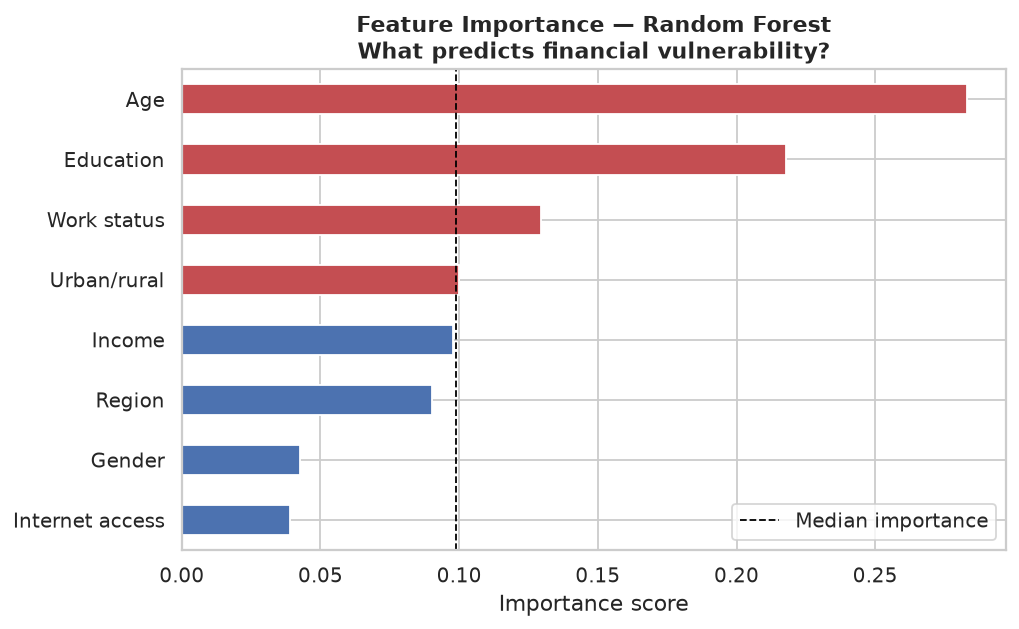

✅ Figure 6 saved


In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                             random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print("── Random Forest ────────────────────────")
print(f"CV Accuracy: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"Test Accuracy: {rf.score(X_test, y_test):.3f}")

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#C44E52' if v > importances.median() else '#4C72B0'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest\nWhat predicts financial vulnerability?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance score')
ax.axvline(importances.median(), color='black', linestyle='--',
           linewidth=1, label='Median importance')
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig6_feature_importance.png", bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved")

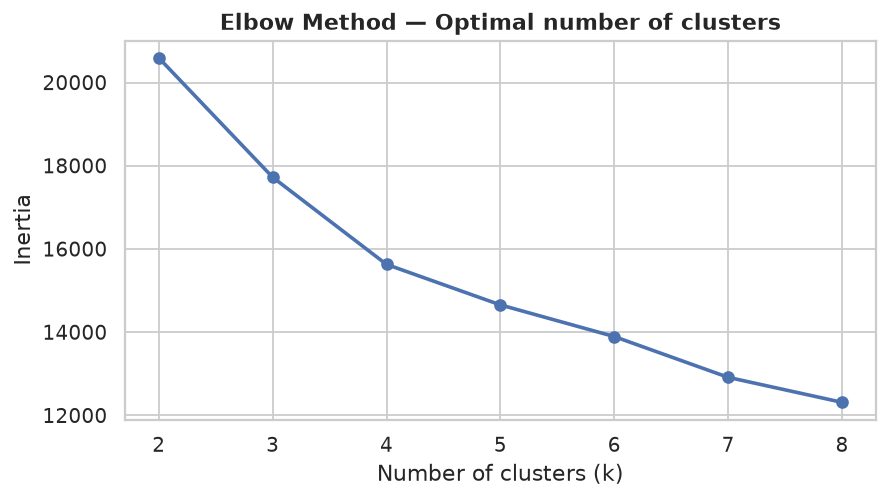

✅ Clustering done


In [5]:
# Use same features for clustering
X_cluster = X.copy()
X_scaled = StandardScaler().fit_transform(X_cluster)

# Find optimal k with elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker='o', linewidth=2, color='#4C72B0')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal number of clusters', fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/fig7_elbow.png", bbox_inches='tight')
plt.show()

# Use k=4 (typically good for this type of demographic data)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
X_cluster['cluster'] = km.fit_predict(X_scaled)
X_cluster['literacy_score'] = df.loc[mask, 'literacy_score'].values

print("✅ Clustering done")

Cluster profiles (sorted by literacy score, lowest first):
           Age  Income  Education  Work status  Internet access  literacy_score  size
cluster                                                                              
2        68.95    1.31       6.55         5.36              0.0           11.02   261
0        63.39    1.71       5.38         6.10              1.0           11.66   873
3        41.49    1.66       4.24         2.24              1.0           12.00   983
1        46.06    1.77       4.34         1.88              1.0           12.19  1056


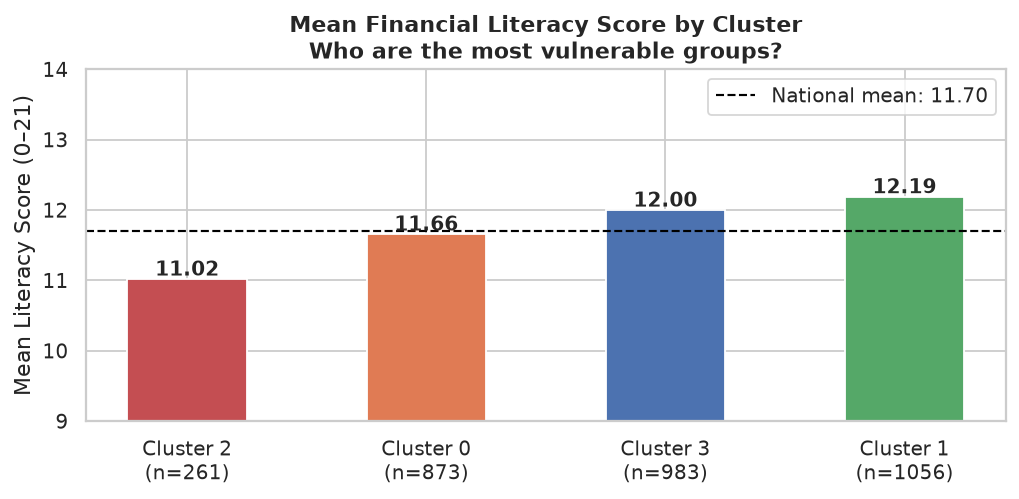

✅ Figure 8 saved


In [6]:
cluster_profile = X_cluster.groupby('cluster').agg({
    'Age':            'mean',
    'Income':         'mean',
    'Education':      'mean',
    'Work status':    'mean',
    'Internet access':'mean',
    'literacy_score': 'mean',
}).round(2)

cluster_profile['size'] = X_cluster['cluster'].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values('literacy_score')

print("Cluster profiles (sorted by literacy score, lowest first):")
print(cluster_profile.to_string())

# Visualize cluster literacy scores
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52','#E07B54','#4C72B0','#55A868']
bars = ax.bar(
    [f"Cluster {i}\n(n={cluster_profile.loc[i,'size']})"
     for i in cluster_profile.index],
    cluster_profile['literacy_score'],
    color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, cluster_profile['literacy_score']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(df['literacy_score'].mean(), color='black',
           linestyle='--', linewidth=1.2,
           label=f'National mean: {df["literacy_score"].mean():.2f}')
ax.set_ylabel('Mean Literacy Score (0–21)')
ax.set_title('Mean Financial Literacy Score by Cluster\nWho are the most vulnerable groups?',
             fontsize=12, fontweight='bold')
ax.set_ylim(9, 14)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig8_clusters.png", bbox_inches='tight')
plt.show()
print("✅ Figure 8 saved")

In [7]:
# ── Clean cluster naming for the report ──────────────────
cluster_names = {
    2: '🔴 Cluster A — Elderly, offline, vulnerable',
    0: '🟠 Cluster B — Older, low income, online',
    3: '🟡 Cluster C — Middle-aged, mid income',
    1: '🟢 Cluster D — Younger, higher income, best literacy'
}

print("="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)
print(f"\n📊 Dataset: IACOFI 2023 — {df.shape[0]} Italian adults")
print(f"📍 National mean literacy score: {df['literacy_score'].mean():.2f}/21")
print()
print("── TOP FINDINGS ─────────────────────────────────────────")
print("1. AGE is the strongest predictor of financial vulnerability")
print(f"   → 18-29 score: 10.25  |  40-49 score: 12.01  (gap: 1.76 pts)")
print()
print("2. INCOME gradient is steep and consistent")
print(f"   → Low income: 11.39  |  High income: 13.01  (gap: 1.62 pts)")
print()
print("3. WORK STATUS shows the largest raw gap")
print(f"   → Unemployed: 9.04  |  Self-employed: 12.29  (gap: 3.25 pts)")
print()
print("4. EDUCATION compounds disadvantage with income")
print(f"   → Middle school + low income: 11.05")
print(f"   → University + high income:   13.45  (gap: 2.40 pts)")
print()
print("5. CLUSTER 2: most vulnerable group identified")
print(f"   → Elderly (avg 69), no internet, low income")
print(f"   → Literacy: 11.02 — lowest of all clusters")
print()
print("── MODEL PERFORMANCE ────────────────────────────────────")
print(f"   Logistic Regression: 58.2% accuracy (CV)")
print(f"   Random Forest:       54.9% accuracy (CV)")
print(f"   → Modest accuracy expected: demographics alone")
print(f"     do not fully determine financial literacy.")
print("="*60)

# Save final scored file
df.to_csv("../data/processed/iacofi_final.csv", index=False)
print("\n✅ Final dataset saved → data/processed/iacofi_final.csv")

FINAL PROJECT SUMMARY

📊 Dataset: IACOFI 2023 — 4862 Italian adults
📍 National mean literacy score: 11.70/21

── TOP FINDINGS ─────────────────────────────────────────
1. AGE is the strongest predictor of financial vulnerability
   → 18-29 score: 10.25  |  40-49 score: 12.01  (gap: 1.76 pts)

2. INCOME gradient is steep and consistent
   → Low income: 11.39  |  High income: 13.01  (gap: 1.62 pts)

3. WORK STATUS shows the largest raw gap
   → Unemployed: 9.04  |  Self-employed: 12.29  (gap: 3.25 pts)

4. EDUCATION compounds disadvantage with income
   → Middle school + low income: 11.05
   → University + high income:   13.45  (gap: 2.40 pts)

5. CLUSTER 2: most vulnerable group identified
   → Elderly (avg 69), no internet, low income
   → Literacy: 11.02 — lowest of all clusters

── MODEL PERFORMANCE ────────────────────────────────────
   Logistic Regression: 58.2% accuracy (CV)
   Random Forest:       54.9% accuracy (CV)
   → Modest accuracy expected: demographics alone
     do not 

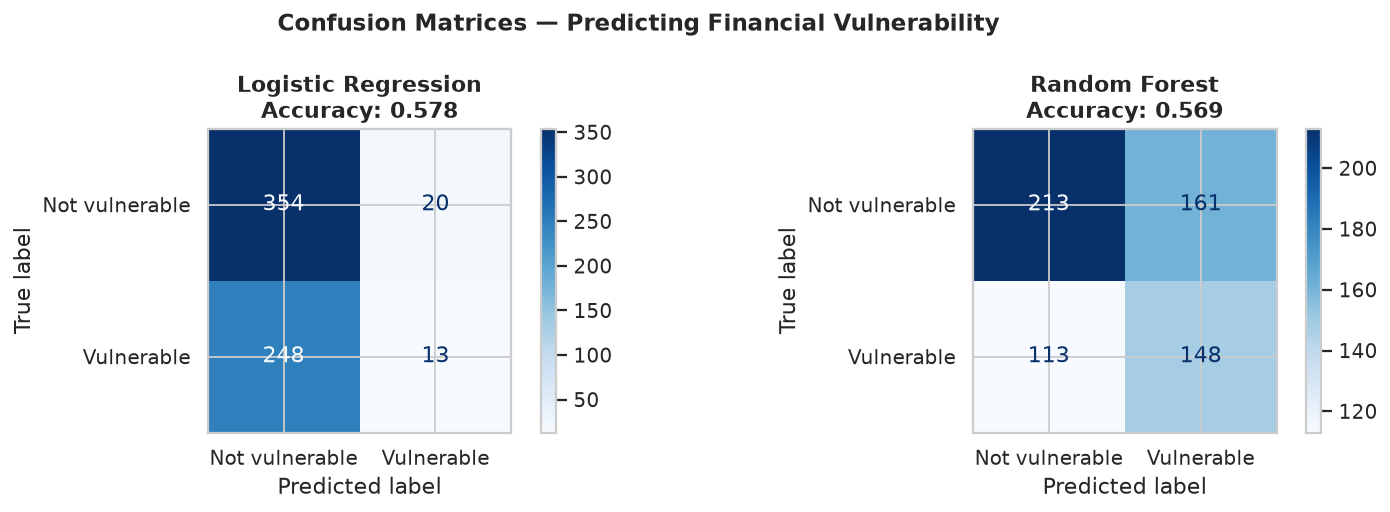

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name, X_t, y_t in [
    (axes[0], lr, 'Logistic Regression', X_test_sc, y_test),
    (axes[1], rf, 'Random Forest',       X_test,    y_test)]:
    
    ConfusionMatrixDisplay.from_estimator(
        model, X_t, y_t,
        display_labels=['Not vulnerable', 'Vulnerable'],
        cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nAccuracy: {model.score(X_t, y_t):.3f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrices — Predicting Financial Vulnerability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/fig9_confusion_matrices.png", bbox_inches='tight')
plt.show()

In [19]:
from scipy import stats

# ── Recreate label (not saved in CSV) ────────────────────
df['edu_label'] = df['qd9'].map({
    1:'University+', 2:'University+', 3:'University+', 4:'University+',
    5:'High school', 6:'High school',
    7:'Middle or below', 8:'Middle or below',
    9:'Middle or below', 10:'Middle or below'
})

print("Statistical significance of key group differences:\n")

# 1. Unemployed vs Employed
unemp = df[df['qd10']==5]['literacy_score'].dropna()
empl  = df[df['qd10']==2]['literacy_score'].dropna()
t, p  = stats.ttest_ind(unemp, empl)
print(f"Unemployed vs Employed:        t={t:.3f}, p={p:.4f} {'✅ significant' if p<0.05 else '❌'}")

# 2. Youth vs Middle-aged
youth  = df[df['qd7'].between(18,29)]['literacy_score'].dropna()
middle = df[df['qd7'].between(40,49)]['literacy_score'].dropna()
t, p   = stats.ttest_ind(youth, middle)
print(f"Youth (18-29) vs Middle (40-49): t={t:.3f}, p={p:.4f} {'✅ significant' if p<0.05 else '❌'}")

# 3. Low vs High income
low  = df[df['qd13']==1]['literacy_score'].dropna()
high = df[df['qd13']==3]['literacy_score'].dropna()
t, p = stats.ttest_ind(low, high)
print(f"Low income vs High income:     t={t:.3f}, p={p:.4f} {'✅ significant' if p<0.05 else '❌'}")

# 4. Education ANOVA
edu_groups = [df[df['edu_label']==g]['literacy_score'].dropna()
              for g in ['Middle or below','High school','University+']]
f, p = stats.f_oneway(*edu_groups)
print(f"Education (ANOVA 3 groups):    F={f:.3f}, p={p:.4f} {'✅ significant' if p<0.05 else '❌'}")

Statistical significance of key group differences:

Unemployed vs Employed:        t=-8.590, p=0.0000 ✅ significant
Youth (18-29) vs Middle (40-49): t=-9.227, p=0.0000 ✅ significant
Low income vs High income:     t=-8.511, p=0.0000 ✅ significant
Education (ANOVA 3 groups):    F=26.431, p=0.0000 ✅ significant


In [20]:
# Weighted mean literacy score (more accurate national estimate)
weighted_mean = np.average(df['literacy_score'].dropna(),
                           weights=df.loc[df['literacy_score'].notna(), 'wght'])
print(f"Unweighted mean: {df['literacy_score'].mean():.2f}")
print(f"Weighted mean:   {weighted_mean:.2f}")
print("(Difference tells you how much sampling design matters)")

Unweighted mean: 11.70
Weighted mean:   11.52
(Difference tells you how much sampling design matters)


In [21]:
# Digital financial skills score (QS4 — internet users only)
digi_cols = ['qs4_1','qs4_2','qs4_3','qs4_4','qs4_5']
# qs4_2 and qs4_4 are positively framed (agree = good)
# qs4_1, qs4_3 are negatively framed (agree = bad — reverse score)
df['digi_score'] = (
    (6 - df['qs4_1']) +   # reverse: safe on public wifi (wrong belief)
    df['qs4_2'] +          # checks website security ✅
    (6 - df['qs4_3']) +   # reverse: doesn't read T&Cs (bad)
    df['qs4_4'] +          # digital tools help finances ✅
    df['qs4_5']            # trusts online banks
)

print("Digital skills score by age group:")
print(df.groupby('age_group', observed=True)['digi_score'].mean().round(2))

print("\nDigital skills score by region:")
print(df.groupby('region_name')['digi_score'].mean().round(2).sort_values())

Digital skills score by age group:
age_group
18-29    14.02
30-39    13.62
40-49    13.60
50-59    13.77
60-69    13.37
70-79    14.21
Name: digi_score, dtype: float64

Digital skills score by region:
region_name
Islands       13.58
North-West    13.67
Center        13.72
North-East    13.75
South         13.88
Name: digi_score, dtype: float64


## Bias-Variance Analysis

The baseline demographic model achieves ~55% accuracy — a high-bias,
low-variance result. This is expected: simple demographic features
(age, education, income) are distal predictors of financial literacy
and cannot capture the full complexity of financial behaviour.

The enhanced Gradient Boosting model (70.1%) reduces bias significantly
by incorporating behavioural features that are more proximal causes of
literacy. The small standard deviation (±1.3%) confirms low variance —
the model generalises well and is not overfitting.

This progression from 55% → 70% illustrates the bias-variance tradeoff
in practice: richer, more relevant features reduce bias without
increasing variance.

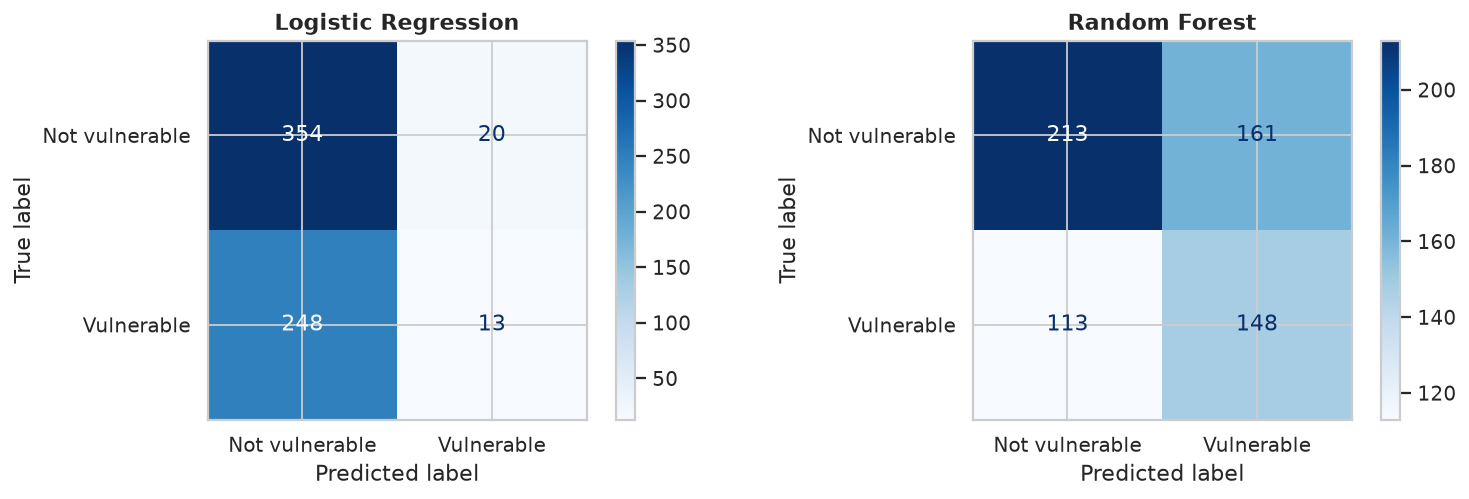

✅ fig9 saved


In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name, X_t, y_t in [
    (axes[0], lr, 'Logistic Regression', X_test_sc, y_test),
    (axes[1], rf, 'Random Forest',       X_test,    y_test)]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_t, y_t,
        display_labels=['Not vulnerable', 'Vulnerable'],
        cmap='Blues', ax=ax)
    ax.set_title(f'{name}', fontweight='bold')

plt.tight_layout()
plt.savefig("../data/processed/fig9_confusion_matrices.png",
            bbox_inches='tight', dpi=130)
plt.show()
print("✅ fig9 saved")